# 01 — Source coverage and data validation
## Context & methods
One pinned [official PhonePe Pulse release](https://github.com/PhonePe/pulse/tree/943e6e52a71513d683f804add12d0b61145e8007), covering 2018 Q1–2026 Q2. We preserve one state-quarter or district-quarter row across transaction, user and merchant families. Categories belong to state-quarter and must not multiply district rows.

### Key assumptions
Registered users and merchants are cumulative stocks; transaction count/value are quarterly flows. A missing source observation is unknown, not zero. Source names are normalized without guessing renamed boundaries. Comparisons across time assume the source geography is comparable; administrative changes need field checks. MySQL stores INR values to two decimal places; count reconciliation is exact and geography amount reconciliation permits at most ₹1 of rounding.

## tl;dr

- Preserved **1,224 state-quarter** and **26,622 district-quarter** records from the pinned official source.
- Passed **31 source-quality checks** and **44 independent SQL/Pandas comparisons**.
- Reconciled transaction counts exactly across state, district, and category grains while retaining historical nulls.
- Demonstrates: source provenance, grain definition, null handling, key validation, reconciliation, and independent calculation checks.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from phonepe_analytics.analysis import ANALYSIS_DIR, MEASURES
from phonepe_analytics.config import EDA_CHART_DIR, PROCESSED_DIR

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
PURPLE, TEAL, GRAY = "#5F259F", "#087F8C", "#697386"
EDA_CHART_DIR.mkdir(parents=True, exist_ok=True)


def save_chart(fig, name):
    fig.tight_layout()
    fig.savefig(EDA_CHART_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


district = pd.read_csv(ANALYSIS_DIR / "district_metrics.csv")
state = pd.read_csv(ANALYSIS_DIR / "state_metrics.csv")
national = pd.read_csv(ANALYSIS_DIR / "national_metrics.csv").sort_values("period_id")
latest_period = district.period_id.max()
latest = district.loc[district.period_id.eq(latest_period)].copy()
state_latest = state.loc[state.period_id.eq(latest_period)].copy()
eligible = pd.read_csv(ANALYSIS_DIR / "district_opportunities.csv")
period = latest.period_label.iloc[0]

## Data — recompute the checks from the processed source

In [2]:
import json

from phonepe_analytics.analysis import verify_sql_exports
from phonepe_analytics.validate import validate_categories, validate_processed_data

raw_state = pd.read_parquet(PROCESSED_DIR / "state_quarter.parquet")
raw_district = pd.read_parquet(PROCESSED_DIR / "district_quarter.parquet")
categories = pd.read_parquet(PROCESSED_DIR / "state_transaction_categories.parquet")
checks, reconciliation = validate_processed_data(raw_state, raw_district)
category_check = validate_categories(raw_state, categories)
comparison_checks = verify_sql_exports()
manifest = json.loads((PROCESSED_DIR / "source_manifest.json").read_text())
display(
    pd.DataFrame(
        {
            "Source": [manifest["repository"]],
            "Commit": [manifest["commit"]],
            "Retrieved UTC": [manifest["retrieved_utc"]],
        }
    )
)
display(checks)
display(
    Markdown(
        f"**Results:** {len(raw_state):,} state-quarter rows and "
        f"{len(raw_district):,} district-quarter rows; {len(checks)} quality checks "
        f"and {len(comparison_checks)} independent SQL/Pandas comparisons pass."
    )
)

,Source,Commit,Retrieved UTC
0,https://github.com/PhonePe/pulse,943e6e52a71513d683f804add12d0b61145e8007,2026-09-11T10:31:48.749752+00:00


,check,table,failures
0,nonempty_table,state,0
1,invalid_period_id,state,0
2,duplicate_logical_keys,state,0
3,null_state,state,0
4,invalid_year,state,0
5,invalid_quarter,state,0
6,negative_transaction_count,state,0
7,negative_transaction_amount,state,0
8,negative_registered_users,state,0
9,negative_registered_merchants,state,0


**Results:** 1,224 state-quarter rows and 26,622 district-quarter rows; 31 quality checks and 44 independent SQL/Pandas comparisons pass.

## Results — missingness and coverage over time

,State missing,District missing
transaction_count,0,6
transaction_amount,0,6
registered_users,0,0
registered_merchants,46,1885


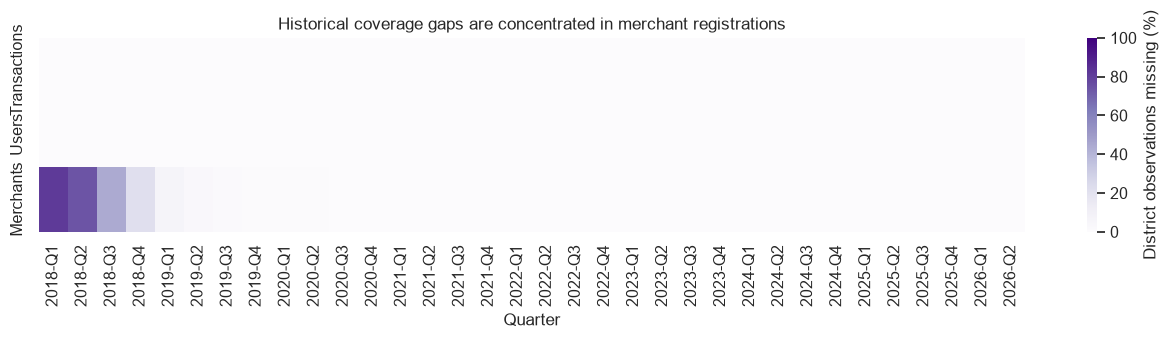

In [3]:
coverage = raw_district.groupby("period_id").agg(
    districts=("district", "size"),
    transactions_observed=("transaction_count", "count"),
    users_observed=("registered_users", "count"),
    merchants_observed=("registered_merchants", "count"),
)
display(
    pd.DataFrame(
        {
            "State missing": raw_state[MEASURES[:4]].isna().sum(),
            "District missing": raw_district[MEASURES[:4]].isna().sum(),
        }
    )
)
missing_by_quarter = 100 * (1 - coverage.iloc[:, 1:].div(coverage.districts, axis=0))
missing_by_quarter.columns = ["Transactions", "Users", "Merchants"]
missing_by_quarter.index = national.period_label
fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(
    missing_by_quarter.T.astype(float),
    cmap="Purples",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "District observations missing (%)"},
    ax=ax,
)
ax.set(
    title="Historical coverage gaps are concentrated in merchant registrations", xlabel="Quarter"
)
save_chart(fig, "01_missingness_by_quarter")

**Insight:** 6 historical district rows lack transactions; 1,885 lack merchant counts. At state level, 46 merchant observations are missing. Dropping these rows would silently change the analytical population. The SQL union of family keys preserves them; incomplete national merchant totals remain null. Historical intensity and penetration comparisons must therefore use only quarters with reported denominators.

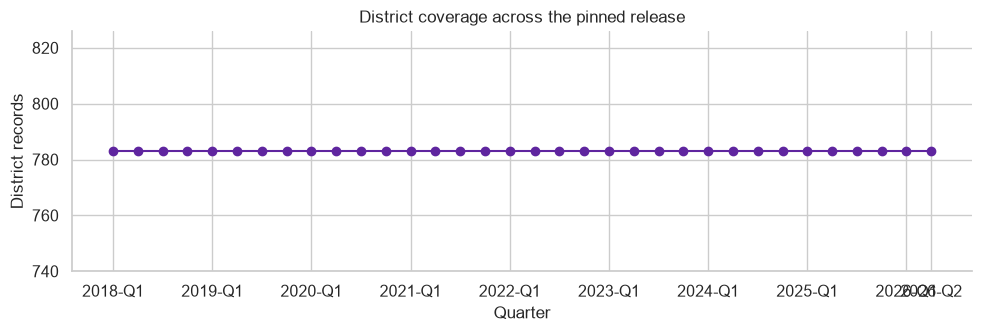

**Insight:** quarterly coverage ranges from 783 to 783 districts. Counts alone cannot prove stable boundaries. Growth uses exact previous-quarter and previous-year keys, and the latest decision snapshot has 783 districts with complete core fields. This supports cross-sectional comparison, while historical geographic continuity remains an interpretation limit.

In [4]:
display(
    Markdown(
        f"**Insight:** {raw_district.transaction_count.isna().sum()} historical district rows lack "
        f"transactions; {raw_district.registered_merchants.isna().sum():,} lack merchant counts. "
        f"At state level, {raw_state.registered_merchants.isna().sum()} merchant "
        f"observations are missing. "
        "Dropping these rows would silently change the analytical population. The SQL "
        "union of family "
        "keys preserves them; incomplete national merchant totals remain null. "
        "Historical intensity "
        "and penetration comparisons must therefore use only quarters with reported denominators."
    )
)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(national.period_label, coverage.districts.to_numpy(), marker="o", color=PURPLE)
ticks = sorted(set([0, *range(4, len(national), 4), len(national) - 1]))
ax.set_xticks(ticks, national.period_label.iloc[ticks])
ax.set(
    title="District coverage across the pinned release", ylabel="District records", xlabel="Quarter"
)
save_chart(fig, "01_district_coverage")
display(
    Markdown(
        f"**Insight:** quarterly coverage ranges from {coverage.districts.min()} to "
        f"{coverage.districts.max()} districts. Counts alone cannot prove stable boundaries. "
        "Growth uses exact previous-quarter and previous-year keys, and the latest "
        "decision snapshot "
        f"has {len(latest)} districts with complete core fields. This supports cross-sectional "
        "comparison, while historical geographic continuity remains an interpretation limit."
    )
)

### Reconciliation and category coverage

In [5]:
display(reconciliation.filter(like="difference").abs().max().rename("Maximum absolute gap"))
expected_grid = pd.MultiIndex.from_product(
    [raw_state.state.unique(), raw_state.period_id.unique(), categories.category.unique()],
    names=["state", "period_id", "category"],
)
missing_categories = expected_grid.difference(
    categories.set_index(["state", "period_id", "category"]).index
)
display(missing_categories.to_frame(index=False))
display(
    Markdown(
        f"**Insight:** all {len(category_check):,} state-quarter category totals reconcile exactly "
        "to transaction counts. One category combination is absent in the source; "
        "retain the absence "
        "as unknown in coverage displays. Reconciliation verifies arithmetic completeness but does "
        "not independently prove a missing category was measured as zero. Retail/P2P/Utility are "
        "state-level counts; district totals cannot be interpreted as merchant sales."
    )
)

transaction_count_difference            0.0
transaction_amount_difference      0.304199
registered_users_difference             0.0
registered_merchants_difference         0.0
Name: Maximum absolute gap, dtype: Float64

,state,period_id,category
0,lakshadweep,8072,Utility


**Insight:** all 1,224 state-quarter category totals reconcile exactly to transaction counts. One category combination is absent in the source; retain the absence as unknown in coverage displays. Reconciliation verifies arithmetic completeness but does not independently prove a missing category was measured as zero. Retail/P2P/Utility are state-level counts; district totals cannot be interpreted as merchant sales.

## Takeaways
Use the latest complete district snapshot for EDA and rankings. Preserve historical nulls, aggregate registration stocks within a quarter only, and recompute ratios from totals. Source counts reconcile across geography and categories; all SQL ratios, growth fields, scores and segments are checked against Pandas. These checks validate the transformations, not PhonePe's collection process or active acceptance coverage.